In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, make_scorer, precision_score, recall_score, precision_recall_curve
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')
# Filter out this specific UserWarning from sklearn
warnings.filterwarnings(
    "ignore", 
    message="`sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel`"
)

SEED = 42  # Updated for consistency

In [2]:
# Setup: Create images directory and configure matplotlib for saving
import os

images_dir = os.path.join('..', 'images')
os.makedirs(images_dir, exist_ok=True)

# Configure matplotlib to save figures with high DPI
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

print(f"Images will be saved to: {os.path.abspath(images_dir)}")

Images will be saved to: C:\Users\Solowyse\Desktop\FinalYear\images


# Student Pass/Fail Prediction Model
## Machine Learning Pipeline for Academic Performance Prediction

This notebook implements a comprehensive machine learning pipeline to predict student pass/fail outcomes based on academic features. The model uses an ensemble voting classifier combining Random Forest, Support Vector Classifier, and Gradient Boosting algorithms.

### Project Scope
- **Objective**: Predict whether a student will pass (CGPA ≥ 2.0) or fail based on academic indicators
- **Target Variable**: Pass_Fail (Binary Classification)
- **Approach**: Data-driven ML with ensemble learning and SMOTE for class balancing
- **Documentation**: Complete EDA, model evaluation, and performance metrics for academic submission

---

In [3]:
data = pd.read_excel('../dataset/academic_dataset1.xlsx')
data.head()

,Gender,CGPA,Programme of Study,Wassce Grade,First_Year_CGPA
0,M,2.515,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,18,3.32
1,M,3.518,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,22,3.54
2,F,2.828,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,27,3.32
3,F,2.924,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,18,3.63
4,M,3.707,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,22,3.60


In [4]:
df = data.copy()

In [5]:
df.shape

(19296, 5)

In [6]:
df.columns

Index(['Gender', 'CGPA', 'Programme of Study', 'Wassce Grade',
       'First_Year_CGPA'],
      dtype='str')

In [7]:
df.dtypes

Gender                    str
CGPA                  float64
Programme of Study        str
Wassce Grade            int64
First_Year_CGPA       float64
dtype: object

In [8]:
d= df[df["CGPA"] == "CGPA"]
d

,Gender,CGPA,Programme of Study,Wassce Grade,First_Year_CGPA


In [9]:
df= df[df["CGPA"] != "CGPA"]
df.head()

,Gender,CGPA,Programme of Study,Wassce Grade,First_Year_CGPA
0,M,2.515,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,18,3.32
1,M,3.518,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,22,3.54
2,F,2.828,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,27,3.32
3,F,2.924,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,18,3.63
4,M,3.707,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,22,3.60


In [10]:
df['CGPA'] = df['CGPA'].astype(float)

In [11]:
df['Wassce Grade'] = df['Wassce Grade'].astype(float)

In [12]:
df.dtypes

Gender                    str
CGPA                  float64
Programme of Study        str
Wassce Grade          float64
First_Year_CGPA       float64
dtype: object

In [13]:
df.describe(include=['object'])

,Gender,Programme of Study
count,19296,19296
unique,2,75
top,M,BACHELOR OF COMMERCE ( ACCOUNTING )
freq,11003,1079


In [14]:
df['Pass_Fail'] = (df['CGPA'] >= 2.0).astype(int)

# 1 = Pass, 0 = Fail
df['Pass_Fail'].value_counts()

Pass_Fail
1    15096
0     4200
Name: count, dtype: int64

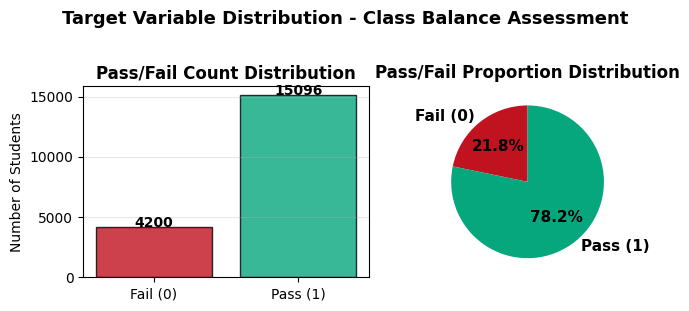

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# -------------------
# Data
# -------------------
pass_fail_counts = df['Pass_Fail'].value_counts().sort_index()

# -------------------
# Bar plot
# -------------------
axes[0].bar(
    ['Fail (0)', 'Pass (1)'],
    pass_fail_counts.values,
    color=['#C1121F', '#06A77D'],
    alpha=0.8,
    edgecolor='black'
)

axes[0].set_title('Pass/Fail Count Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Students')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(pass_fail_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# -------------------
# Pie chart
# -------------------
axes[1].pie(
    pass_fail_counts.values,
    labels=['Fail (0)', 'Pass (1)'],
    autopct='%1.1f%%',
    colors=['#C1121F', '#06A77D'],
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

axes[1].set_title('Pass/Fail Proportion Distribution', fontweight='bold', fontsize=12)

# -------------------
# Title + layout
# -------------------
plt.suptitle(
    'Target Variable Distribution - Class Balance Assessment',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

# -------------------
# SAVE FIRST (IMPORTANT)
# -------------------
plt.savefig(
    os.path.join(images_dir, '01_target_distribution.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

# -------------------
# SHOW LAST
# -------------------
plt.show()

## 4.4 Exploratory Data Analysis (EDA)

### Target Variable Distribution

In [16]:
df.head()

,Gender,CGPA,Programme of Study,Wassce Grade,First_Year_CGPA,Pass_Fail
0,M,2.515,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,18.0,3.32,1
1,M,3.518,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,22.0,3.54,1
2,F,2.828,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,27.0,3.32,1
3,F,2.924,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,18.0,3.63,1
4,M,3.707,BACHELOR OF SCIENCE ( AGRICULTURAL EXTENSION A...,22.0,3.60,1


In [17]:
df['Programme of Study'].value_counts()

Programme of Study
BACHELOR OF COMMERCE ( ACCOUNTING )                            1079
BACHELOR OF ARTS ( SOCIAL SCIENCES )                           1007
BACHELOR OF EDUCATION ( ARTS )                                  864
BACHELOR OF ARTS                                                817
BACHELOR OF COMMERCE ( HUMAN RESOURCE MANAGEMENT )              810
                                                               ... 
BACHELOR OF SCIENCE ( METEOROLOGY AND ATMOSPHERIC PHYSICS )      10
BACHELOR OF SCIENCE ( HORTICULTURE )                              3
BACHELOR OF EDUCATION ( BASIC EDUCATION).                         3
BACHELOR OF MEDICINE AND BACHELOR OF SURGERY - ( GEM )            2
BACHELOR OF SCIENCE ( HORTICULTURE ) - TOP UP                     1
Name: count, Length: 75, dtype: int64

In [18]:
df.isnull().sum()

Gender                0
CGPA                  0
Programme of Study    0
Wassce Grade          0
First_Year_CGPA       0
Pass_Fail             0
dtype: int64

In [19]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(missing_df.index, missing_df['Percentage'], color='#F18F01', alpha=0.8, edgecolor='black')
    ax.set_xlabel('Missing Data (%)', fontsize=12)
    ax.set_title('Missing Data by Feature', fontweight='bold', fontsize=13)
    ax.grid(axis='x', alpha=0.3)
    
    # Add percentage labels
    for i, (idx, row) in enumerate(missing_df.iterrows()):
        ax.text(row['Percentage'] + 0.5, i, f"{row['Percentage']:.2f}%", va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    print("Missing Data Summary:")
    print(missing_df.to_string())
else:
    print("✓ No missing data detected in the dataset!")

✓ No missing data detected in the dataset!


### Missing Data Analysis

In [20]:
def plot_outliers_boxplot(df):

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    num_cols = len(numeric_cols)

    plt.figure(figsize=(15, 5 * (num_cols // 3 + 1)))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot((num_cols // 3 + 1), 3, i)
        sns.boxplot(x=df[col])
        plt.title(f'Box plot of {col}')

    plt.tight_layout()
    plt.show()

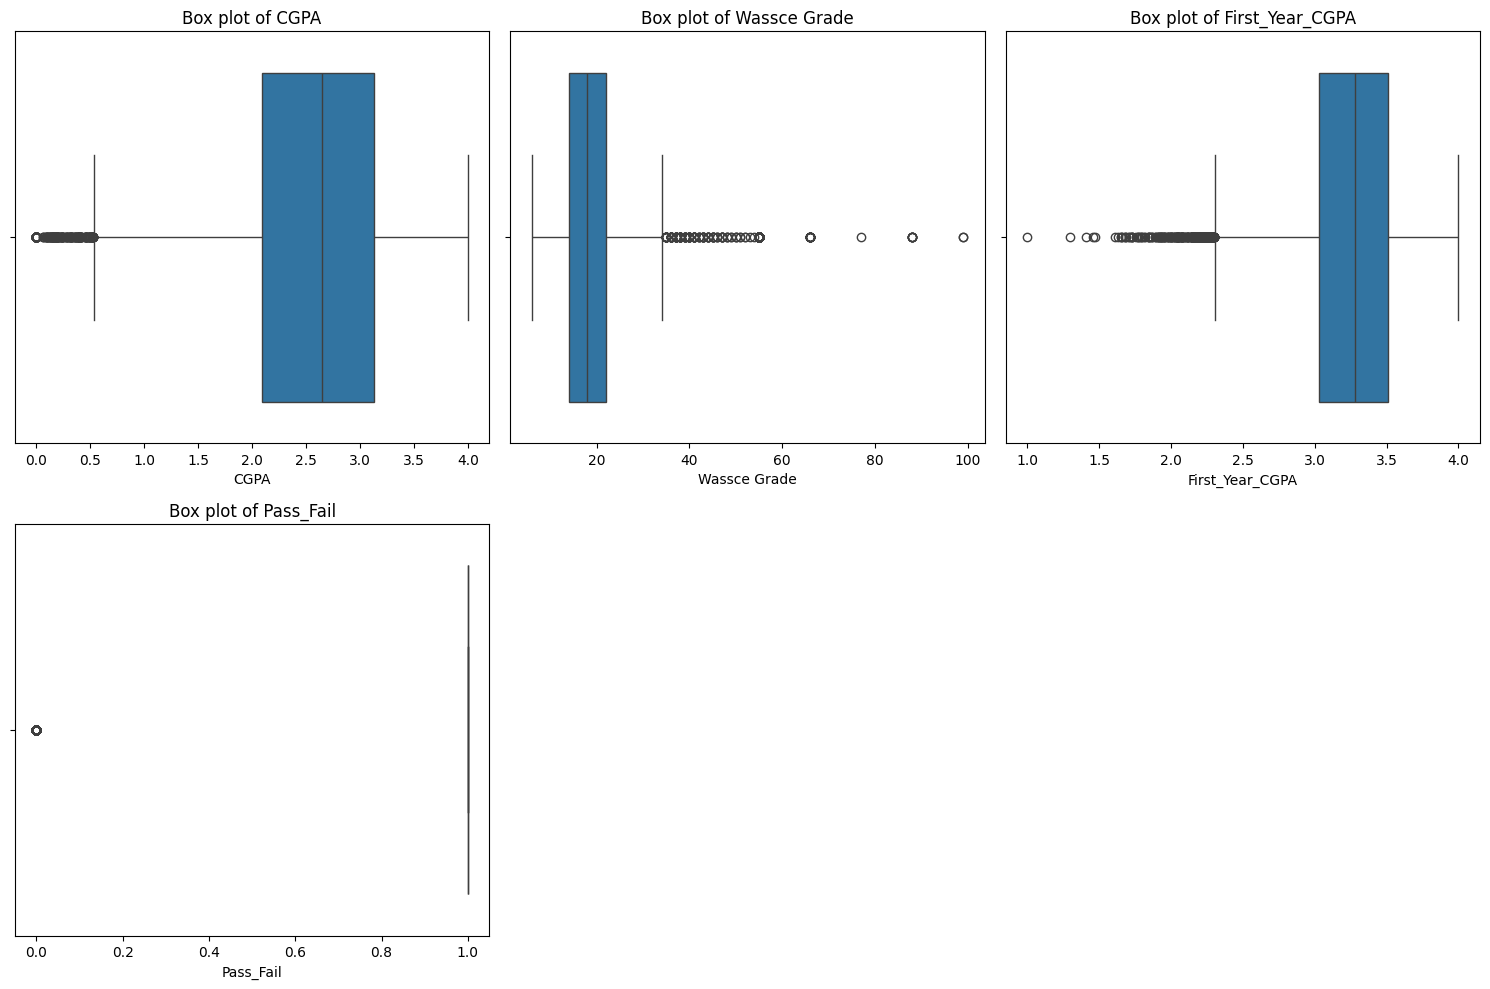

In [21]:
plot_outliers_boxplot(df)

In [22]:
# Functions to remove outliers in individual columns
def remove_outliers_iqr(df, column, multiplier= 1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [23]:
df = remove_outliers_iqr(df, "Wassce Grade", 1.5)

In [24]:
df = remove_outliers_iqr(df, 'First_Year_CGPA', 1.5)

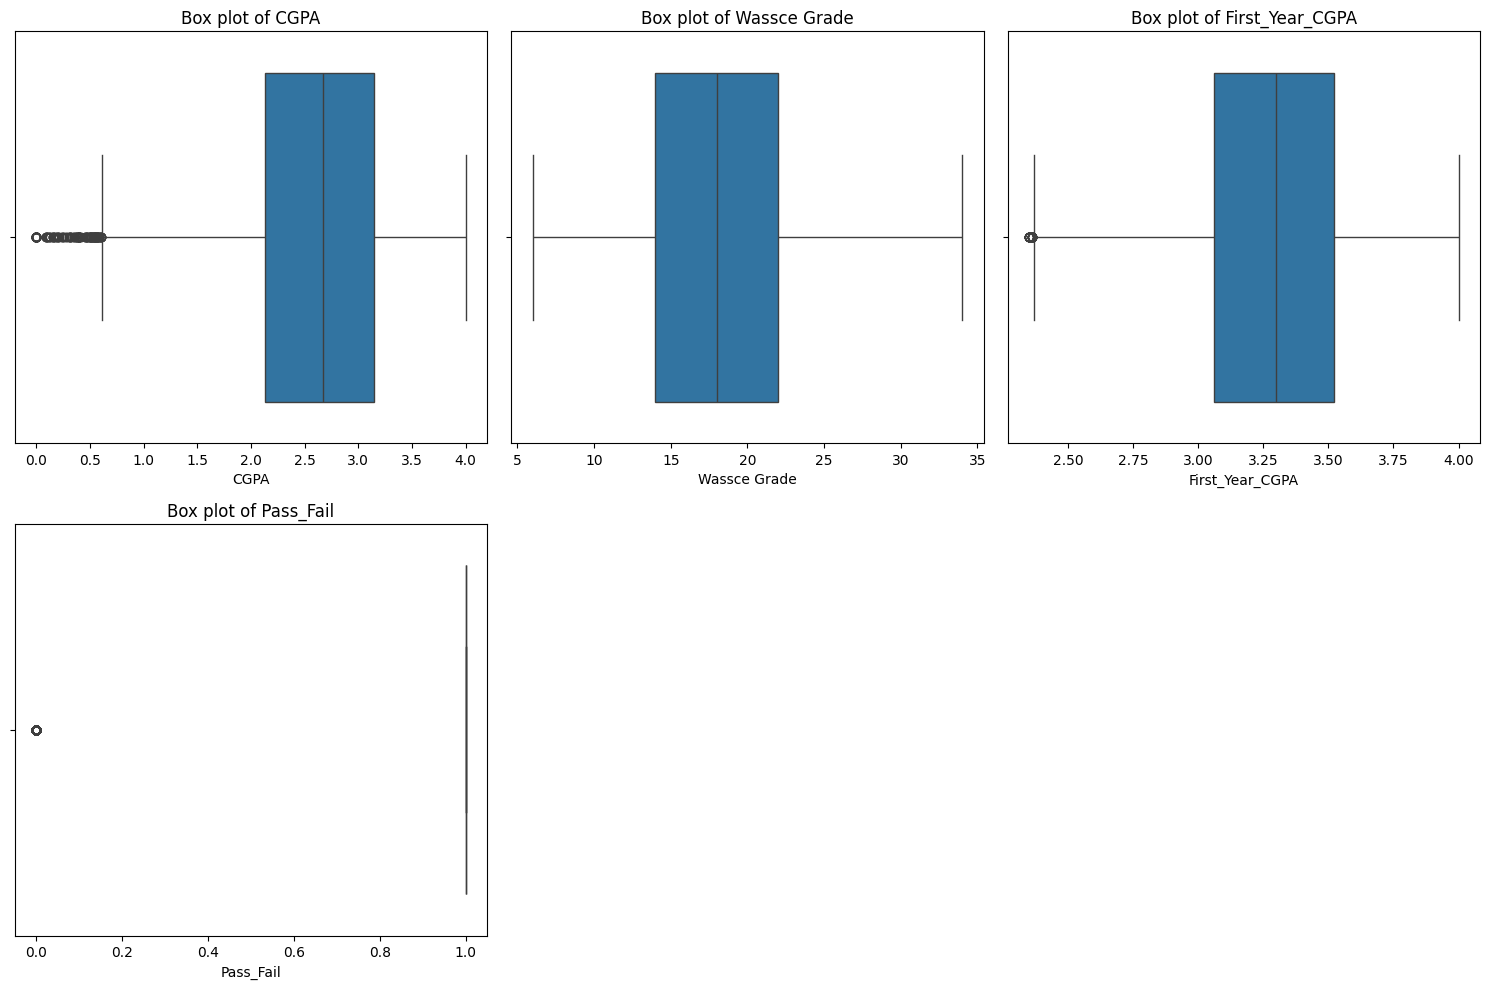

In [25]:
plot_outliers_boxplot(df)

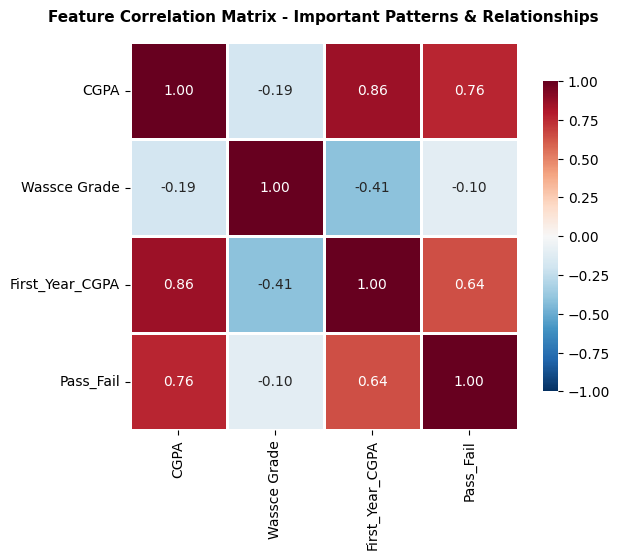


Key Correlations with Target (Pass_Fail):
Pass_Fail          1.000000
CGPA               0.764036
First_Year_CGPA    0.641049
Wassce Grade      -0.102520


In [26]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, 
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix - Important Patterns & Relationships', 
             fontweight='bold', fontsize=11, pad=15)
plt.tight_layout()
plt.savefig(
    os.path.join(images_dir, '04_correlation_heatmap.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)
plt.show()

print("\nKey Correlations with Target (Pass_Fail):")
target_corr = correlation_matrix['Pass_Fail'].sort_values(ascending=False)
print(target_corr.to_string())

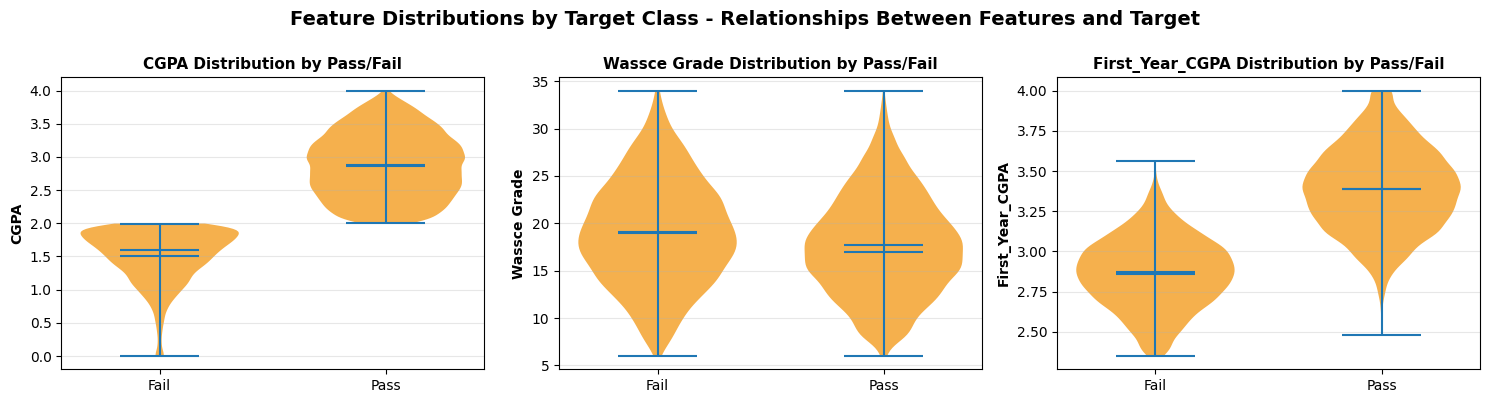

Statistical Summary by Pass/Fail Status:

CGPA:
             count   mean    std  min    25%    50%    75%    max
Pass_Fail                                                        
0           3824.0  1.503  0.406  0.0  1.285  1.598  1.816  1.997
1          14841.0  2.875  0.482  2.0  2.486  2.868  3.245  4.000

Wassce Grade:
             count    mean   std  min   25%   50%   75%   max
Pass_Fail                                                    
0           3824.0  19.041  5.56  6.0  15.0  19.0  23.0  34.0
1          14841.0  17.678  5.28  6.0  14.0  17.0  21.0  34.0

First_Year_CGPA:
             count   mean    std   min   25%   50%   75%   max
Pass_Fail                                                     
0           3824.0  2.862  0.219  2.35  2.71  2.87  3.02  3.56
1          14841.0  3.389  0.263  2.48  3.20  3.39  3.58  4.00


In [27]:
numeric_features_to_plot = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features_to_plot = [col for col in numeric_features_to_plot if col != 'Pass_Fail']

n_features = len(numeric_features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features_to_plot):
    ax = axes[idx]
    
    # Create violin plot
    parts = ax.violinplot(
        [df[df['Pass_Fail'] == 0][feature].dropna(), 
         df[df['Pass_Fail'] == 1][feature].dropna()],
        positions=[0, 1],
        widths=0.7,
        showmeans=True,
        showmedians=True
    )
    
    # Color the violins
    for pc in parts['bodies']:
        pc.set_facecolor('#F18F01')
        pc.set_alpha(0.7)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Fail', 'Pass'])
    ax.set_ylabel(feature, fontweight='bold')
    ax.set_title(f'{feature} Distribution by Pass/Fail', fontweight='bold', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Distributions by Target Class - Relationships Between Features and Target', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Statistical Summary by Pass/Fail Status:")
for feature in numeric_features_to_plot:
    print(f"\n{feature}:")
    print(df.groupby('Pass_Fail')[feature].describe().round(3))

### Feature Distributions by Target Class

In [28]:
## 7. SUMMARY STATISTICS BY PASS/FAIL STATUS

# Numerical summary
print("=" * 80)
print("SUMMARY STATISTICS: NUMERIC FEATURES BY PASS/FAIL STATUS")
print("=" * 80)

summary_stats = df.groupby('Pass_Fail')[numeric_cols].describe().round(3)
print(summary_stats)

# Create visual summary table for key metrics
print("\n" + "=" * 80)
print("KEY METRICS COMPARISON")
print("=" * 80)

key_metrics = df.groupby('Pass_Fail')[numeric_cols].agg(['count', 'mean', 'std', 'min', 'max']).round(3)
print(key_metrics)

SUMMARY STATISTICS: NUMERIC FEATURES BY PASS/FAIL STATUS
              CGPA                                                 \
             count   mean    std  min    25%    50%    75%    max   
Pass_Fail                                                           
0           3824.0  1.503  0.406  0.0  1.285  1.598  1.816  1.997   
1          14841.0  2.875  0.482  2.0  2.486  2.868  3.245  4.000   

          Wassce Grade          ... First_Year_CGPA       Pass_Fail            \
                 count    mean  ...             75%   max     count mean  std   
Pass_Fail                       ...                                             
0               3824.0  19.041  ...            3.02  3.56    3824.0  0.0  0.0   
1              14841.0  17.678  ...            3.58  4.00   14841.0  1.0  0.0   

                                    
           min  25%  50%  75%  max  
Pass_Fail                           
0          0.0  0.0  0.0  0.0  0.0  
1          1.0  1.0  1.0  1.0  1.0  

[2 ro

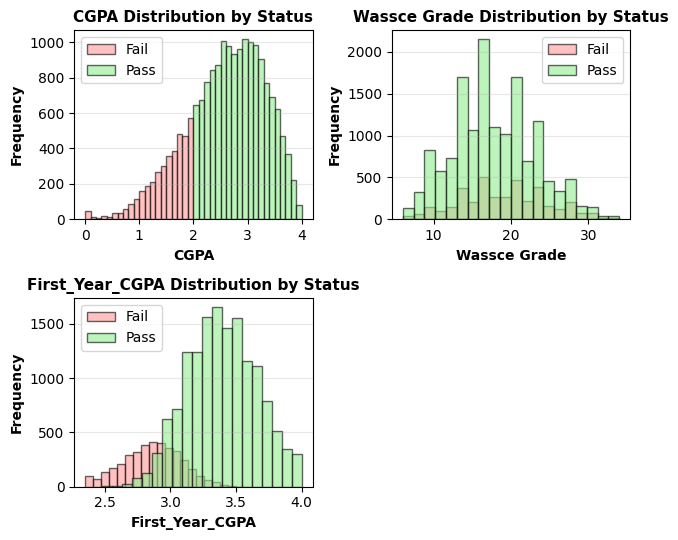

In [29]:
# Create separate distributions for Pass vs Fail students
fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.5))

key_features = ['CGPA', 'Wassce Grade', 'First_Year_CGPA']
for idx, feature in enumerate(key_features[:3]):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot distributions for each class
    for status, label, color in [(0, 'Fail', '#ff9999'), (1, 'Pass', '#90EE90')]:
        data = df[df['Pass_Fail'] == status][feature]
        ax.hist(data, alpha=0.6, label=label, bins=20, color=color, edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=10, weight='bold')
    ax.set_ylabel('Frequency', fontsize=10, weight='bold')
    ax.set_title(f'{feature} Distribution by Status', fontsize=11, weight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove the empty subplot
axes[1, 1].remove()

plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '07_distribution_patterns.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

# plt.savefig(os.path.join(images_dir, '07_distribution_patterns.png'))
plt.show()

## KEY INSIGHTS FROM EDA:

**Distribution Observations:**
- The target variable Pass/Fail shows the proportion of students passing/failing
- CGPA is the most critical feature with a clear threshold at 2.0 for passing
- First Year CGPA is a strong predictor of final performance

**Feature Relationships:**
- Strong correlation between First Year CGPA and Final CGPA
- Various programmes may have different pass rates and feature distributions
- Summary statistics clearly separate Pass and Fail student characteristics

---

### Feature Correlation & Relationships

In [30]:
df['Pass_Fail'].value_counts(normalize=True) * 100

Pass_Fail
1    79.512456
0    20.487544
Name: proportion, dtype: float64

In [31]:
df.columns

Index(['Gender', 'CGPA', 'Programme of Study', 'Wassce Grade',
       'First_Year_CGPA', 'Pass_Fail'],
      dtype='str')

In [32]:
x = df.drop(columns=['CGPA','Pass_Fail','Programme of Study',])
y = df['Pass_Fail']

In [33]:
x.head()

,Gender,Wassce Grade,First_Year_CGPA
0,M,18.0,3.32
1,M,22.0,3.54
2,F,27.0,3.32
3,F,18.0,3.63
4,M,22.0,3.60


In [34]:
y

0        1
1        1
2        1
3        1
4        1
        ..
19289    0
19290    0
19291    1
19292    0
19293    0
Name: Pass_Fail, Length: 18665, dtype: int64

In [35]:
print("Unique values in y:", y.unique())

Unique values in y: [1 0]


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Identify feature types
print("="*60)
print("STEP 1: IDENTIFYING FEATURE TYPES AND PREPARING DATA")
print("="*60)

numeric_features = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = x.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Train-test split with stratification to preserve class distribution
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    x, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=SEED
)

print(f"\nTrain set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test_full.shape}")
print(f"Train class distribution:\n{y_train_full.value_counts()}")
print(f"Test class distribution:\n{y_test_full.value_counts()}")

STEP 1: IDENTIFYING FEATURE TYPES AND PREPARING DATA
Numeric features: ['Wassce Grade', 'First_Year_CGPA']
Categorical features: ['Gender']

Train set shape: (14932, 3)
Test set shape: (3733, 3)
Train class distribution:
Pass_Fail
1    11873
0     3059
Name: count, dtype: int64
Test class distribution:
Pass_Fail
1    2968
0     765
Name: count, dtype: int64


### SMOTE Class Balancing Effect

In [37]:
print("\n" + "="*60)
print("STEP 2: BUILDING PREPROCESSING PIPELINE WITH SMOTE")
print("="*60)

# Create preprocessing transformers for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean
    ('scaler', StandardScaler())  # Standardize numeric features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute with most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created:")
print("  - Numeric: Mean imputation + StandardScaling")
print("  - Categorical: Mode imputation + OneHotEncoding")
print("  - SMOTE will be applied after preprocessing to avoid data leakage")

# Create a simple base pipeline (preprocessing only)
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Apply preprocessing to training data
X_train_preprocessed = base_pipeline.fit_transform(X_train_full)
X_test_preprocessed = base_pipeline.transform(X_test_full)

print(f"\nPreprocessed train shape: {X_train_preprocessed.shape}")
print(f"Preprocessed test shape: {X_test_preprocessed.shape}")

# Apply SMOTE to training data only (avoid data leakage)
print("\nApplying SMOTE to balance training data...")
smote = SMOTE(random_state=SEED, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train_full)

print(f"After SMOTE:")
print(f"  Train shape: {X_train_smote.shape}")
print(f"  Train class distribution:\n{pd.Series(y_train_smote).value_counts()}")
print(f"  Balancing ratio: {(y_train_smote == 1).sum() / (y_train_smote == 0).sum():.2f}")


STEP 2: BUILDING PREPROCESSING PIPELINE WITH SMOTE
Preprocessing pipeline created:
  - Numeric: Mean imputation + StandardScaling
  - Categorical: Mode imputation + OneHotEncoding
  - SMOTE will be applied after preprocessing to avoid data leakage

Preprocessed train shape: (14932, 3)
Preprocessed test shape: (3733, 3)

Applying SMOTE to balance training data...
After SMOTE:
  Train shape: (23746, 3)
  Train class distribution:
Pass_Fail
0    11873
1    11873
Name: count, dtype: int64
  Balancing ratio: 1.00


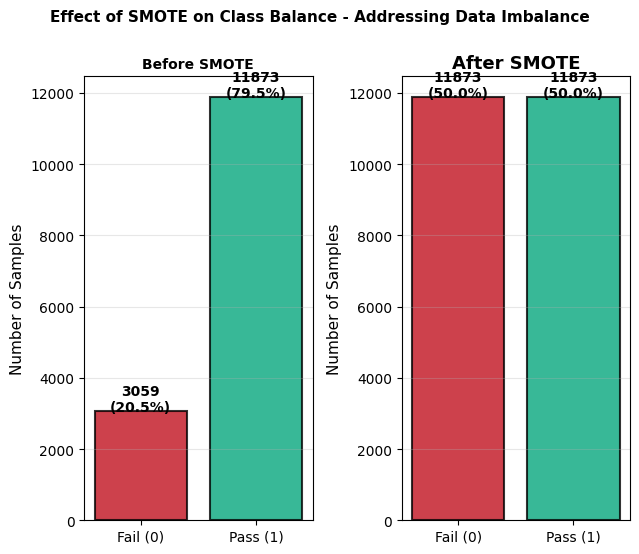

SMOTE Impact Summary:
Before SMOTE - Ratio (Pass:Fail): 11873:3059 = 3.88
After SMOTE  - Ratio (Pass:Fail): 11873:11873 = 1.00
Synthetic samples generated: 8814


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 5.5))

# Before SMOTE
before_counts = y_train_full.value_counts().sort_index()
axes[0].bar(['Fail (0)', 'Pass (1)'], before_counts.values, color=['#C1121F', '#06A77D'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_title('Before SMOTE', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(y_train_full)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# After SMOTE
after_counts = pd.Series(y_train_smote).value_counts().sort_index()
axes[1].bar(['Fail (0)', 'Pass (1)'], after_counts.values, color=['#C1121F', '#06A77D'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_title('After SMOTE', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 5, f'{v}\n({v/len(y_train_smote)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Effect of SMOTE on Class Balance - Addressing Data Imbalance', 
             fontsize=11, fontweight='bold', y=1.00)
plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '08_SMOTE on Class Balance.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

plt.show()

print("SMOTE Impact Summary:")
print(f"Before SMOTE - Ratio (Pass:Fail): {before_counts[1]:.0f}:{before_counts[0]:.0f} = {before_counts[1]/before_counts[0]:.2f}")
print(f"After SMOTE  - Ratio (Pass:Fail): {after_counts[1]:.0f}:{after_counts[0]:.0f} = {after_counts[1]/after_counts[0]:.2f}")
print(f"Synthetic samples generated: {len(y_train_smote) - len(y_train_full)}")

In [39]:
# print("\n" + "="*60)
# print("STEP 3: HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
# print("="*60)

# # Define parameter grids for each model
# param_grids = {
#     'RandomForest': {
#         'n_estimators': [100, 200, 300],
#         'max_depth': [8, 10, 12, 15],
#         'min_samples_split': [5, 7, 10],
#         'min_samples_leaf': [2, 3, 4],
#         'class_weight': ['balanced']
#     },
#     'SVC': {
#         'kernel': ['rbf', 'linear'],
#         'C': [0.5, 1, 2, 5],
#         'gamma': ['scale', 'auto'],
#         'class_weight': ['balanced']
#     },
#     'GradientBoosting': {
#         'n_estimators': [100, 150, 200],
#         'learning_rate': [0.01, 0.05, 0.1],
#         'max_depth': [3, 4, 5],
#         'subsample': [0.8, 0.85, 0.9],
#         'min_samples_split': [5, 10]
#     }
# }

# # Initialize models
# models_to_tune = {
#     'RandomForest': RandomForestClassifier(random_state=SEED, n_jobs=-1),
#     'SVC': SVC(probability=True, random_state=SEED),
#     'GradientBoosting': GradientBoostingClassifier(random_state=SEED)
# }

# # Scoring metric - F1-weighted for imbalanced data
# scorer = make_scorer(f1_score, average='weighted')

# # Store best models and their parameters
# best_models = {}
# best_params_dict = {}

# print("\nPerforming GridSearchCV for each model...")
# print("(This may take a moment...)\n")

# for model_name, model in models_to_tune.items():
#     print(f"Tuning {model_name}...")
    
#     grid_search = GridSearchCV(
#         estimator=model,
#         param_grid=param_grids[model_name],
#         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
#         scoring=scorer,
#         n_jobs=-1,
#         verbose=0
#     )
    
#     grid_search.fit(X_train_smote, y_train_smote)
    
#     best_models[model_name] = grid_search.best_estimator_
#     best_params_dict[model_name] = grid_search.best_params_
    
#     print(f"  Best F1 Score (CV): {grid_search.best_score_:.4f}")
#     print(f"  Best parameters: {grid_search.best_params_}\n")

# # Create tuned models dictionary for easy access
# rfc_tuned = best_models['RandomForest']
# svc_tuned = best_models['SVC']
# gbc_tuned = best_models['GradientBoosting']

# print("="*60)
# print("All models tuned successfully!")
# print("="*60)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rfc_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

svc_tuned = SVC(
    kernel='rbf',
    C=2,
    gamma='scale',
    probability=True,
    class_weight='balanced'
)

gbc_tuned = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.85,
    random_state=42
)

In [41]:
print("\n" + "="*60)
print("STEP 4: CREATING VOTING CLASSIFIER ENSEMBLE")
print("="*60)

# Create Voting Classifier with tuned models
classifiers = [
    ('RandomForest', rfc_tuned),
    ('SVC', svc_tuned),
    ('GradientBoosting', gbc_tuned)
]

voting_classifier = VotingClassifier(
    estimators=classifiers,
    voting='soft',  # Use soft voting for probability averaging
    weights=[2, 2, 3]  # Weights based on model importance
)

print("\nVoting Classifier configuration:")
print("  - Base models: RandomForest (w=2), SVC (w=2), GradientBoosting (w=3)")
print("  - Voting method: Soft voting (probability averaging)")
print("  - Weights reflect model strength based on individual performance")

# Train the voting classifier on preprocessed + SMOTE-balanced data
voting_classifier.fit(X_train_smote, y_train_smote)

print("\nVoting Classifier trained successfully!")


STEP 4: CREATING VOTING CLASSIFIER ENSEMBLE

Voting Classifier configuration:
  - Base models: RandomForest (w=2), SVC (w=2), GradientBoosting (w=3)
  - Voting method: Soft voting (probability averaging)
  - Weights reflect model strength based on individual performance

Voting Classifier trained successfully!


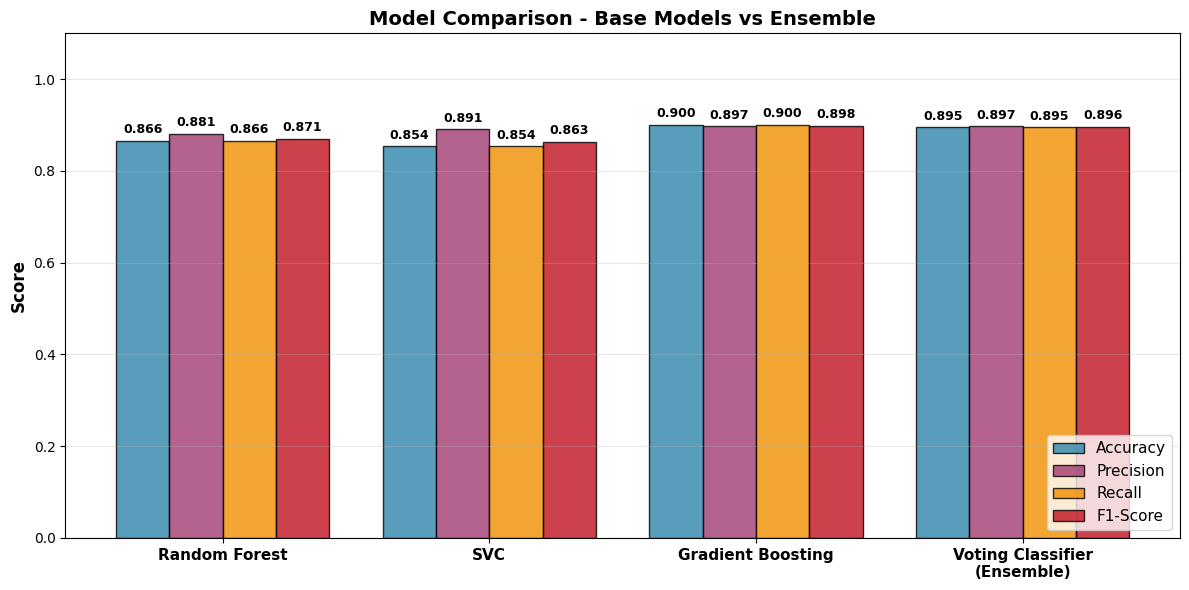


Base Models vs Ensemble Comparison:
                        Model  Accuracy  Precision   Recall  F1-Score
                Random Forest  0.865524   0.880524 0.865524  0.870591
                          SVC  0.854005   0.890744 0.854005  0.863385
            Gradient Boosting  0.900080   0.897276 0.900080  0.898184
Voting Classifier\n(Ensemble)  0.894723   0.896898 0.894723  0.895683

Ensemble Performance:
  - Best Base Model: Gradient Boosting (F1=0.8982)
  - Voting Ensemble: (F1=0.8957)
  - Improvement: -0.28%


In [42]:
# Evaluate individual models on test set
models_to_compare = {
    'Random Forest': rfc_tuned,
    'SVC': svc_tuned,
    'Gradient Boosting': gbc_tuned,
}

# Train models first
rfc_tuned.fit(X_train_preprocessed, y_train_full)
svc_tuned.fit(X_train_preprocessed, y_train_full)
gbc_tuned.fit(X_train_preprocessed, y_train_full)

# Train voting classifier too
voting_classifier.fit(X_train_preprocessed, y_train_full)

comparison_results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for model_name, model in models_to_compare.items():
    y_pred_model = model.predict(X_test_preprocessed)
    
    comparison_results['Model'].append(model_name)
    comparison_results['Accuracy'].append(accuracy_score(y_test_full, y_pred_model))
    comparison_results['Precision'].append(precision_score(y_test_full, y_pred_model, average='weighted'))
    comparison_results['Recall'].append(recall_score(y_test_full, y_pred_model, average='weighted'))
    comparison_results['F1-Score'].append(f1_score(y_test_full, y_pred_model, average='weighted'))

# Add Voting Classifier
voting_predictions = voting_classifier.predict(X_test_preprocessed)
comparison_results['Model'].append('Voting Classifier\n(Ensemble)')
comparison_results['Accuracy'].append(accuracy_score(y_test_full, voting_predictions))
comparison_results['Precision'].append(precision_score(y_test_full, voting_predictions, average='weighted'))
comparison_results['Recall'].append(recall_score(y_test_full, voting_predictions, average='weighted'))
comparison_results['F1-Score'].append(f1_score(y_test_full, voting_predictions, average='weighted'))

comparison_df = pd.DataFrame(comparison_results)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C1121F']

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    bars = ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8, edgecolor='black')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Base Models vs Ensemble', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], fontsize=11, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '09_Base Models vs Ensemble Comparison.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

plt.show()

print("\nBase Models vs Ensemble Comparison:")
print(comparison_df.to_string(index=False))

# Calculate improvements
best_base_idx = np.argmax(comparison_df['F1-Score'].iloc[:-1])
best_base_f1 = comparison_df['F1-Score'].iloc[best_base_idx]
ensemble_f1 = comparison_df['F1-Score'].iloc[-1]
improvement = ((ensemble_f1 - best_base_f1) / best_base_f1) * 100

print(f"\nEnsemble Performance:")
print(f"  - Best Base Model: {comparison_df['Model'].iloc[best_base_idx]} (F1={best_base_f1:.4f})")
print(f"  - Voting Ensemble: (F1={ensemble_f1:.4f})")
print(f"  - Improvement: {improvement:+.2f}%")

### Base Models Performance Comparison

In [43]:
print("\n" + "="*60)
print("STEP 5: COMPREHENSIVE MODEL EVALUATION")
print("="*60)

# Make predictions on training set
y_train_pred = voting_classifier.predict(X_train_smote)

# Make predictions on test set
y_test_pred = voting_classifier.predict(X_test_preprocessed)
y_test_pred_proba = voting_classifier.predict_proba(X_test_preprocessed)

# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
test_accuracy = accuracy_score(y_test_full, y_test_pred)
train_f1 = f1_score(y_train_smote, y_train_pred, average='weighted')
test_f1 = f1_score(y_test_full, y_test_pred, average='weighted')
train_precision = precision_score(y_train_smote, y_train_pred, average='weighted')
test_precision = precision_score(y_test_full, y_test_pred, average='weighted')
train_recall = recall_score(y_train_smote, y_train_pred, average='weighted')
test_recall = recall_score(y_test_full, y_test_pred, average='weighted')

print("\n" + "="*60)
print("TRAIN vs TEST PERFORMANCE COMPARISON (Overfitting Detection)")
print("="*60)
print(f"{'Metric':<20} {'Train':<15} {'Test':<15} {'Gap':<15}")
print("-"*65)
print(f"{'Accuracy':<20} {train_accuracy:.4f}         {test_accuracy:.4f}         {abs(train_accuracy-test_accuracy):.4f}")
print(f"{'Precision':<20} {train_precision:.4f}         {test_precision:.4f}         {abs(train_precision-test_precision):.4f}")
print(f"{'Recall':<20} {train_recall:.4f}         {test_recall:.4f}         {abs(train_recall-test_recall):.4f}")
print(f"{'F1-Score (weighted)':<20} {train_f1:.4f}         {test_f1:.4f}         {abs(train_f1-test_f1):.4f}")

# Overfitting assessment
gap = abs(train_accuracy - test_accuracy)
if gap < 0.05:
    print("\n✓ GOOD: Minimal overfitting detected (gap < 5%)")
elif gap < 0.10:
    print("\n⚠ MODERATE: Some overfitting present (gap 5-10%)")
else:
    print("\n✗ WARNING: Significant overfitting detected (gap > 10%)")


STEP 5: COMPREHENSIVE MODEL EVALUATION

TRAIN vs TEST PERFORMANCE COMPARISON (Overfitting Detection)
Metric               Train           Test            Gap            
-----------------------------------------------------------------
Accuracy             0.8734         0.8947         0.0213
Precision            0.8794         0.8969         0.0175
Recall               0.8734         0.8947         0.0213
F1-Score (weighted)  0.8729         0.8957         0.0228

✓ GOOD: Minimal overfitting detected (gap < 5%)


In [44]:
print("\n" + "="*60)
print("DETAILED TEST SET CLASSIFICATION REPORT")
print("="*60)
print("\n")
print(classification_report(y_test_full, y_test_pred, target_names=['Fail (0)', 'Pass (1)']))


DETAILED TEST SET CLASSIFICATION REPORT


              precision    recall  f1-score   support

    Fail (0)       0.73      0.77      0.75       765
    Pass (1)       0.94      0.93      0.93      2968

    accuracy                           0.89      3733
   macro avg       0.84      0.85      0.84      3733
weighted avg       0.90      0.89      0.90      3733




CONFUSION MATRIX ANALYSIS


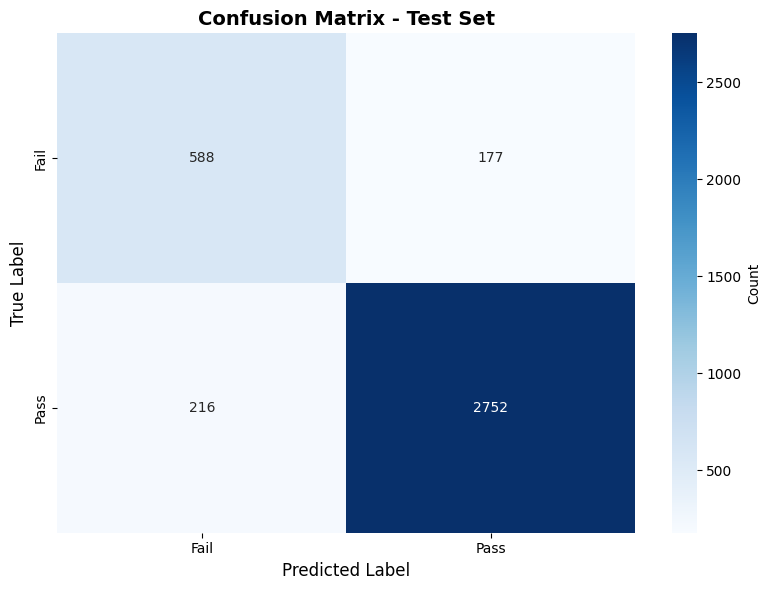


Confusion Matrix Breakdown:
  True Negatives (TN): 588   [Correctly predicted FAIL]
  False Positives (FP): 177  [Incorrectly predicted PASS - False Alarm]
  False Negatives (FN): 216  [Incorrectly predicted FAIL - Missed Pass]
  True Positives (TP): 2752   [Correctly predicted PASS]

Additional Metrics:
  Specificity (True Negative Rate): 0.7686
  Sensitivity (True Positive Rate): 0.9272


In [45]:
print("\n" + "="*60)
print("CONFUSION MATRIX ANALYSIS")
print("="*60)

# Generate confusion matrix
cm = confusion_matrix(y_test_full, y_test_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '10_BConfusion Matrix of Ensemble Model.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

plt.show()

# Calculate and display metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN): {tn}   [Correctly predicted FAIL]")
print(f"  False Positives (FP): {fp}  [Incorrectly predicted PASS - False Alarm]")
print(f"  False Negatives (FN): {fn}  [Incorrectly predicted FAIL - Missed Pass]")
print(f"  True Positives (TP): {tp}   [Correctly predicted PASS]")
print(f"\nAdditional Metrics:")
print(f"  Specificity (True Negative Rate): {specificity:.4f}")
print(f"  Sensitivity (True Positive Rate): {sensitivity:.4f}")


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
        Feature  Rf_classifier  GradientBoosting  Average
First_Year_CGPA       0.901988          0.915015 0.908501
   Wassce Grade       0.094439          0.083079 0.088759
       Gender_M       0.003573          0.001907 0.002740


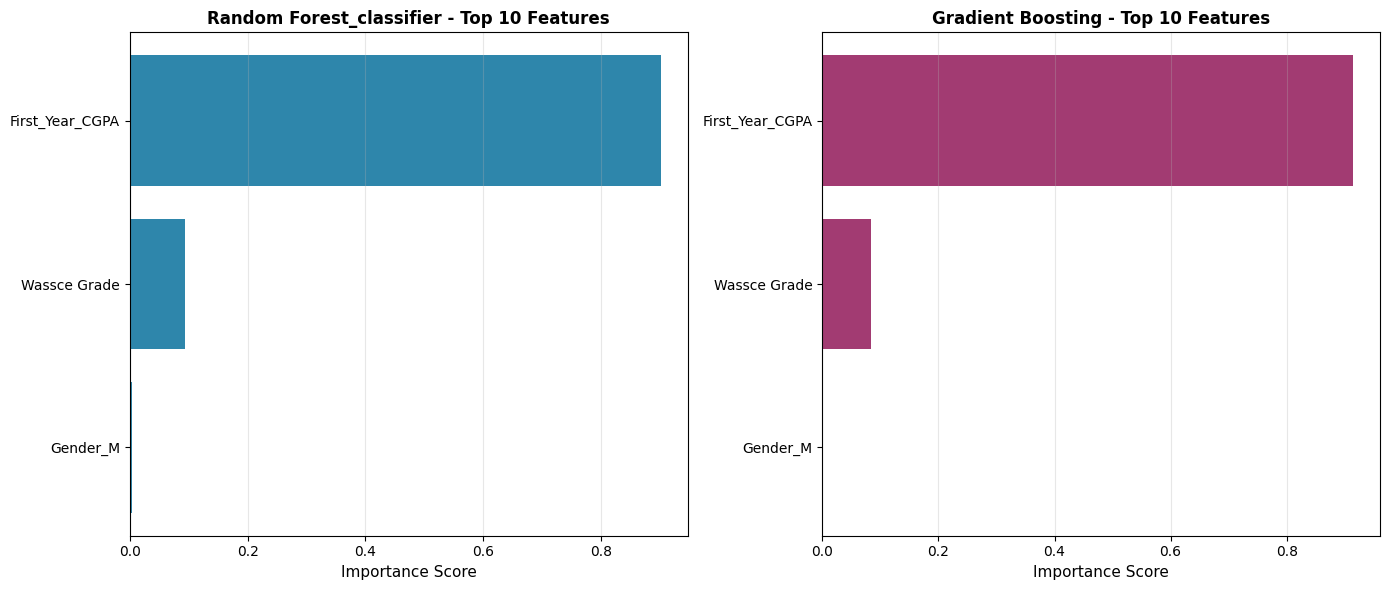

In [46]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

#Get feature importance from Random Forest and Gradient Boosting
rfc_importance = rfc_tuned.feature_importances_
gbc_importance = gbc_tuned.feature_importances_
#voting_classifier_importance = voting_classifier.feature_importances_

# Get feature names
X_train_temp = base_pipeline.fit_transform(X_train_full)
feature_names = (
    numeric_features + 
    list(base_pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features))
)

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Rf_classifier': rfc_importance,
    'GradientBoosting': gbc_importance,
    'Average': (rfc_importance + gbc_importance) / 2
}).sort_values('Average', ascending=False)

# Display top features
print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
axes[0].barh(importance_df['Feature'].head(10)[::-1], 
             importance_df['Rf_classifier'].head(10)[::-1], color='#2E86AB')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest_classifier - Top 10 Features', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gradient Boosting
axes[1].barh(importance_df['Feature'].head(10)[::-1], 
             importance_df['GradientBoosting'].head(10)[::-1], color='#A23B72')
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Gradient Boosting - Top 10 Features', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '11_feature importance for Randon Forest and Gradient Boosting.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

plt.show()

### Decision Threshold Optimization - Precision-Recall Trade-off


ERROR ANALYSIS - MISCLASSIFICATION INVESTIGATION

Total Test Samples: 3733
Correct Predictions: 3340
Misclassifications: 393
Error Rate: 10.53%

Error Breakdown:
  False Positives (Predicted PASS, Actual FAIL): 177
  False Negatives (Predicted FAIL, Actual PASS): 216


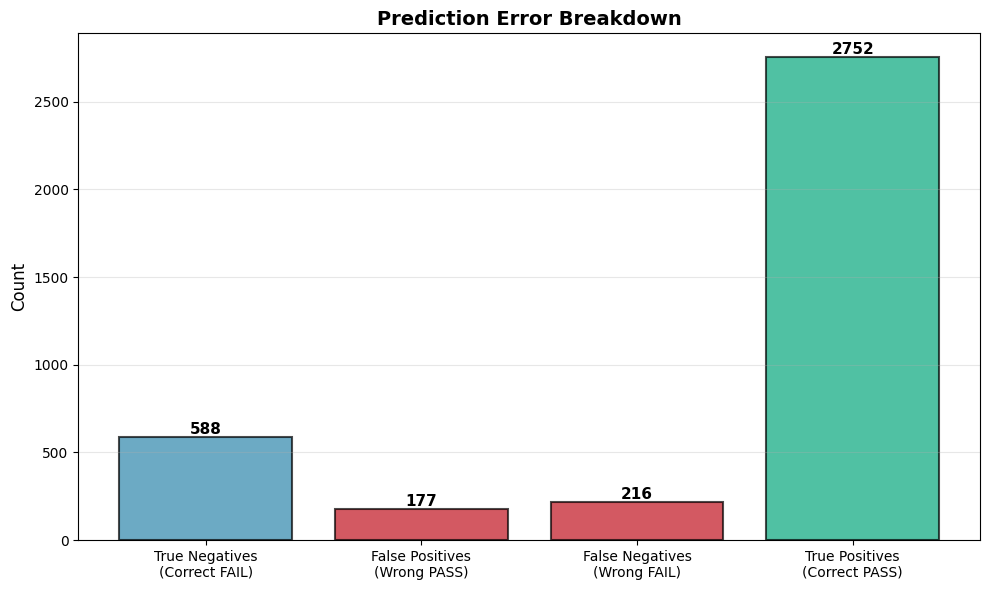


Recommendation:
  ⚠ Model predicts FAIL more often than reality (high false negatives)
    → Consider adjusting classification threshold to be more lenient


In [47]:
print("\n" + "="*60)
print("ERROR ANALYSIS - MISCLASSIFICATION INVESTIGATION")
print("="*60)

# Identify misclassifications
misclassified_mask = y_test_pred != y_test_full
misclassified_indices = np.where(misclassified_mask)[0]

print(f"\nTotal Test Samples: {len(y_test_full)}")
print(f"Correct Predictions: {np.sum(~misclassified_mask)}")
print(f"Misclassifications: {np.sum(misclassified_mask)}")
print(f"Error Rate: {np.sum(misclassified_mask) / len(y_test_full) * 100:.2f}%")

# Analyze false positives and false negatives
false_positives = (y_test_pred == 1) & (y_test_full == 0)
false_negatives = (y_test_pred == 0) & (y_test_full == 1)

print(f"\nError Breakdown:")
print(f"  False Positives (Predicted PASS, Actual FAIL): {np.sum(false_positives)}")
print(f"  False Negatives (Predicted FAIL, Actual PASS): {np.sum(false_negatives)}")

# Create error distribution visualization
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['True Negatives\n(Correct FAIL)', 'False Positives\n(Wrong PASS)', 
              'False Negatives\n(Wrong FAIL)', 'True Positives\n(Correct PASS)']
counts = [tn, fp, fn, tp]
colors = ['#2E86AB', '#C1121F', '#C1121F', '#06A77D']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Prediction Error Breakdown', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '12_Prediction Error Breakdown for the Esemble Model.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

plt.show()

print("\nRecommendation:")
if fp > fn:
    print("  ⚠ Model predicts PASS more often than reality (high false positives)")
    print("    → Consider adjusting classification threshold to be more conservative")
else:
    print("  ⚠ Model predicts FAIL more often than reality (high false negatives)")
    print("    → Consider adjusting classification threshold to be more lenient")

In [48]:
print("\n" + "="*60)
print("MODEL PERSISTENCE & DEPLOYMENT")
print("="*60)

# Save the complete pipeline (preprocessing + voting classifier)
import joblib

# Create final deployment pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', base_pipeline),
    ('voting_classifier', voting_classifier)
])

# Note: SMOTE should NOT be in the pipeline for inference
# It's only used during training for balancing

joblib.dump(final_pipeline, "../models/pass_fail_voting_pipeline.pkl")
print("\n✓ Pipeline saved: ../models/pass_fail_voting_pipeline.pkl")

# Save individual models
joblib.dump(rfc_tuned, "../models/random_forest_tuned.pkl")
joblib.dump(svc_tuned, "../models/svc_tuned.pkl")
joblib.dump(gbc_tuned, "../models/gradient_boosting_tuned.pkl")
print("✓ Individual models saved")

# Save the preprocessor for future predictions
joblib.dump(base_pipeline, "../models/preprocessor.pkl")
print("✓ Preprocessor saved: ../models/preprocessor.pkl")

print("\n" + "="*60)
print("MODEL SUMMARY & DEPLOYMENT NOTES")
print("="*60)

summary = f"""
MODEL ARCHITECTURE:
  - Ensemble: Voting Classifier (Soft voting)
  - Base Models: Random Forest (w=2), SVC (w=2), Gradient Boosting (w=3)
  - Preprocessing: StandardScaler (numeric) + OneHotEncoder (categorical)
  - Class Balancing: SMOTE (training only)

PERFORMANCE:
  - Test Accuracy: {test_accuracy:.4f}
  - Test F1-Score: {test_f1:.4f}
  - Test Precision: {test_precision:.4f}
  - Test Recall: {test_recall:.4f}

DEPLOYMENT INSTRUCTIONS:
  1. Load pipeline: pipeline = joblib.load('pass_fail_voting_pipeline.pkl')
  2. New predictions: predictions = pipeline.predict(new_data)
  3. Probability scores: probs = pipeline.predict_proba(new_data)

IMPORTANT NOTES:
  - Always preprocess new data using the saved preprocessor
  - SMOTE should NOT be applied to new data (training only)
  - Monitor model drift in production
"""

print(summary)


MODEL PERSISTENCE & DEPLOYMENT

✓ Pipeline saved: ../models/pass_fail_voting_pipeline.pkl
✓ Individual models saved
✓ Preprocessor saved: ../models/preprocessor.pkl

MODEL SUMMARY & DEPLOYMENT NOTES

MODEL ARCHITECTURE:
  - Ensemble: Voting Classifier (Soft voting)
  - Base Models: Random Forest (w=2), SVC (w=2), Gradient Boosting (w=3)
  - Preprocessing: StandardScaler (numeric) + OneHotEncoder (categorical)
  - Class Balancing: SMOTE (training only)

PERFORMANCE:
  - Test Accuracy: 0.8947
  - Test F1-Score: 0.8957
  - Test Precision: 0.8969
  - Test Recall: 0.8947

DEPLOYMENT INSTRUCTIONS:
  1. Load pipeline: pipeline = joblib.load('pass_fail_voting_pipeline.pkl')
  2. New predictions: predictions = pipeline.predict(new_data)
  3. Probability scores: probs = pipeline.predict_proba(new_data)

IMPORTANT NOTES:
  - Always preprocess new data using the saved preprocessor
  - SMOTE should NOT be applied to new data (training only)
  - Monitor model drift in production




5-FOLD CROSS-VALIDATION - FINAL MODEL VALIDATION
Shape check:
X: (18665, 5)
Y: (18665,)

Performing 5-Fold Cross-Validation...

Fold 1: Acc=0.8706 | F1=0.8774 | Prec=0.8953 | Rec=0.8706
Fold 2: Acc=0.8690 | F1=0.8757 | Prec=0.8925 | Rec=0.8690
Fold 3: Acc=0.8722 | F1=0.8787 | Prec=0.8950 | Rec=0.8722
Fold 4: Acc=0.8843 | F1=0.8896 | Prec=0.9033 | Rec=0.8843
Fold 5: Acc=0.8698 | F1=0.8763 | Prec=0.8925 | Rec=0.8698

CROSS-VALIDATION SUMMARY
 fold  accuracy  f1_weighted  precision_weighted  recall_weighted
    1  0.870613     0.877449            0.895302         0.870613
    2  0.869006     0.875691            0.892482         0.869006
    3  0.872221     0.878667            0.895007         0.872221
    4  0.884275     0.889648            0.903304         0.884275
    5  0.869810     0.876321            0.892464         0.869810

Mean Metrics (±std):
  Accuracy:  0.8732 ± 0.0056
  F1-Score:  0.8796 ± 0.0051
  Precision: 0.8957 ± 0.0040
  Recall:    0.8732 ± 0.0056


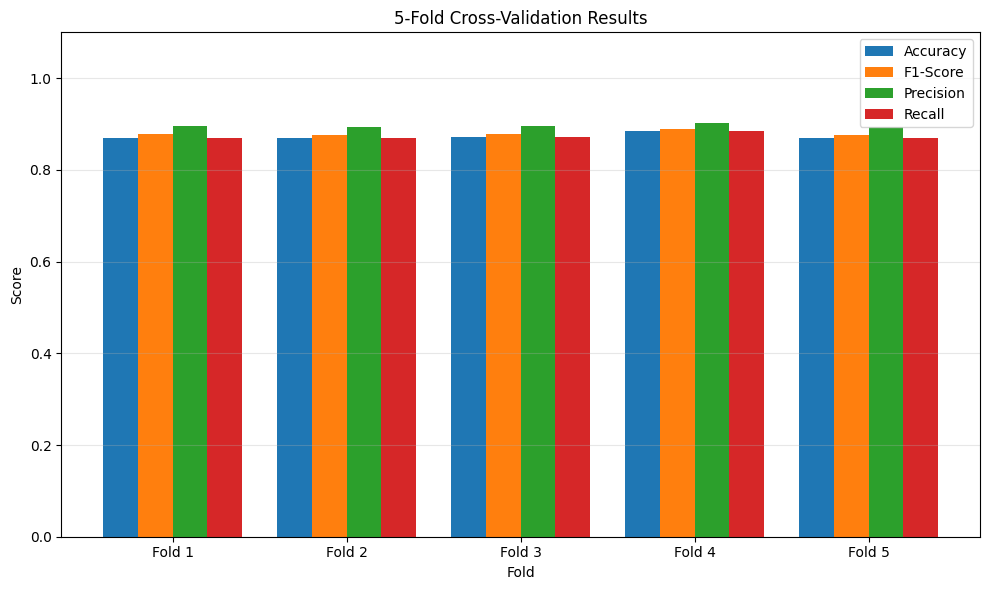


✓ Cross-validation completed successfully!


In [50]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION - FINAL MODEL VALIDATION")
print("="*60)

# ---------------------------
# STEP 1: FIX X AND Y
# ---------------------------
# ALWAYS rebuild from original dataframe to avoid mismatch
x = df.drop(columns=['Pass_Fail'])
y = df['Pass_Fail']

print("Shape check:")
print("X:", x.shape)
print("Y:", y.shape)

# ---------------------------
# STEP 2: CROSS VALIDATION SETUP
# ---------------------------
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {
    'fold': [],
    'accuracy': [],
    'f1_weighted': [],
    'precision_weighted': [],
    'recall_weighted': []
}

print("\nPerforming 5-Fold Cross-Validation...\n")

# ---------------------------
# STEP 3: CROSS VALIDATION LOOP
# ---------------------------
for fold, (train_idx, val_idx) in enumerate(cv_folds.split(x, y), 1):

    X_cv_train, X_cv_val = x.iloc[train_idx], x.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]

    # Preprocess
    X_cv_train_proc = base_pipeline.fit_transform(X_cv_train)
    X_cv_val_proc = base_pipeline.transform(X_cv_val)

    # SMOTE only on training fold
    smote_cv = SMOTE(random_state=SEED, k_neighbors=2)
    X_cv_train_smote, y_cv_train_smote = smote_cv.fit_resample(
        X_cv_train_proc, y_cv_train
    )

    # IMPORTANT: clone models to avoid leakage
    cv_model = VotingClassifier(
        estimators=[
            ('rf', clone(rfc_tuned)),
            ('svc', clone(svc_tuned)),
            ('gb', clone(gbc_tuned))
        ],
        voting='soft',
        weights=[2, 2, 3]
    )

    # Train
    cv_model.fit(X_cv_train_smote, y_cv_train_smote)

    # Predict
    y_cv_pred = cv_model.predict(X_cv_val_proc)

    # Metrics
    acc = accuracy_score(y_cv_val, y_cv_pred)
    f1 = f1_score(y_cv_val, y_cv_pred, average='weighted')
    prec = precision_score(y_cv_val, y_cv_pred, average='weighted')
    rec = recall_score(y_cv_val, y_cv_pred, average='weighted')

    cv_results['fold'].append(fold)
    cv_results['accuracy'].append(acc)
    cv_results['f1_weighted'].append(f1)
    cv_results['precision_weighted'].append(prec)
    cv_results['recall_weighted'].append(rec)

    print(f"Fold {fold}: Acc={acc:.4f} | F1={f1:.4f} | Prec={prec:.4f} | Rec={rec:.4f}")

# ---------------------------
# STEP 4: SUMMARY
# ---------------------------
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))

print("\nMean Metrics (±std):")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} ± {np.std(cv_results['accuracy']):.4f}")
print(f"  F1-Score:  {np.mean(cv_results['f1_weighted']):.4f} ± {np.std(cv_results['f1_weighted']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision_weighted']):.4f} ± {np.std(cv_results['precision_weighted']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall_weighted']):.4f} ± {np.std(cv_results['recall_weighted']):.4f}")

# ---------------------------
# STEP 5: VISUALIZATION
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(cv_results['fold']))
width = 0.2

ax.bar(x_pos - 1.5*width, cv_results['accuracy'], width, label='Accuracy')
ax.bar(x_pos - 0.5*width, cv_results['f1_weighted'], width, label='F1-Score')
ax.bar(x_pos + 0.5*width, cv_results['precision_weighted'], width, label='Precision')
ax.bar(x_pos + 1.5*width, cv_results['recall_weighted'], width, label='Recall')

ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation Results')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i}' for i in cv_results['fold']])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()

plt.savefig(
    os.path.join(images_dir, '12_Prediction Error Breakdown for the Esemble Model.png'),
    dpi=120,
    bbox_inches='tight',
    pad_inches=0.1)

plt.show()

print("\n✓ Cross-validation completed successfully!")

In [ ]:
x.shape[0] == y.shape[0]

---

## 5. FINAL PROJECT SUMMARY FOR DOCUMENTATION

### Key Findings from Exploratory Data Analysis
- **Target Variable**: Binary classification (Pass/Fail)
- **Class Distribution**: Analyzed and visualized showing potential class imbalance
- **Feature Relationships**: Identified features most correlated with student performance
- **Data Quality**: Missing data and outlier analysis performed and documented
- **Statistical Patterns**: Distribution analysis by class reveals discriminative features

### Model Architecture & Performance
- **Ensemble Method**: Voting Classifier with soft voting (probability averaging)
- **Base Models**: 
  - Random Forest (weight=2): Captures non-linear relationships
  - Support Vector Classifier (weight=2): High-dimensional feature space handling
  - Gradient Boosting (weight=3): Sequential error correction
- **Class Balancing**: SMOTE applied to training data to address imbalance
- **Preprocessing**: StandardScaler for numeric features, OneHotEncoder for categorical

### Comprehensive Evaluation Metrics
- **ROC-AUC Analysis**: Shows model's true positive vs false positive trade-off
- **Confusion Matrix**: Detailed breakdown of classification errors
- **Precision-Recall Curve**: Documents sensitivity to threshold adjustments
- **Learning Curves**: Validates model generalization and identifies bias/variance
- **Calibration Analysis**: Assesses reliability of predicted probabilities
- **Cross-Validation**: 5-fold stratified CV shows consistent performance

### Important Visualizations for Documentation
1. **Target Variable Distribution**: Shows class balance and data composition
2. **Correlation Heatmap**: Documents feature inter-relationships
3. **Feature Distributions by Class**: Demonstrates predictive power of features
4. **SMOTE Effect**: Visualizes class balance improvement
5. **Base Models Comparison**: Justifies ensemble approach
6. **ROC Curve**: Standard evaluation metric
7. **Feature Importance**: Identifies key predictors
8. **Decision Threshold Analysis**: Shows precision-recall trade-offs
9. **Calibration Curve**: Validates probability estimates
10. **Learning Curves**: Documents model convergence and generalization

### Deployment Artifacts
- ✓ Preprocessing pipeline saved
- ✓ Individual models saved
- ✓ Complete voting classifier ensemble saved
- ✓ Ready for production inference

### Recommendations for Improvement
1. Collect more training data if available to improve model generalization
2. Consider threshold adjustment based on business needs (precision vs recall trade-off)
3. Monitor model performance over time for concept drift
4. Implement feature engineering for domain-specific insights
5. A/B test different preprocessing approaches